# Pareto Analysis — Port Microgrid Sizing

This notebook solves the bi-objective sizing problem of a port microgrid coupling
photovoltaic (PV) generation with battery energy storage (BESS).

**Objectives**

- *Economic*: minimise the total annualised cost \(C_\text{tot}\) = annualised CAPEX + OPEX
  (grid imports, PV O&M, battery cycling).
- *Environmental / autonomy*: characterise the share of demand covered by local renewables.

**Scenarios**

| Scenario | PV capacity (MW) | Battery capacity (MWh) |
|---|---|---|
| **S0 — Reference** | 0 | 0 |
| **S1 — PV only** | 0 → 100 (step 1) | 0 |
| **S2 — PV + Battery** | 0 → 100 (step 1) | 0 → 15 (step 1) |

**Indicators reported on the Pareto plots**

Two complementary x-axes are used for the same set of LP solutions:

1. **Renewable Energy Coverage**:
   \[ \mathrm{RE\,Coverage} \;=\; \frac{E_\text{demand} - E_\text{imp}}{E_\text{demand}} \;\times\; 100\,\% \]
   → fraction of demand met locally (autonomy view).

2. **PV Share in the Energy Mix**:
   \[ \mathrm{PV\,Share} \;=\; \frac{E_\text{pv}}{E_\text{pv} + E_\text{imp}} \;\times\; 100\,\% \]
   → fraction of solar in the total energy supplied to the system (mix view).

The ordinate of both Pareto plots is the **annual cost differential** with respect to S0:
\(\Delta C = C_\text{tot}^{(S_i)} - C_\text{tot}^{(S_0)}\).


## 1. Imports and solver configuration


In [11]:
import logging
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from tqdm.auto import tqdm

import src.data_prep as dp
import src.power_flow as pfo
import src.config as cfg

# --- Silence verbose loggers ------------------------------------------------
for name in ("pypsa", "linopy", "highspy", "gurobipy"):
    logging.getLogger(name).setLevel(logging.WARNING)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

# --- Publication-ready Matplotlib style -------------------------------------
plt.rcParams.update({
    "font.family":           "serif",
    "font.size":             10,
    "axes.labelsize":        11,
    "axes.titlesize":        11,
    "xtick.labelsize":        9,
    "ytick.labelsize":        9,
    "legend.fontsize":        8,
    "legend.title_fontsize":  8,
    "figure.dpi":           130,
    "axes.grid":           True,
    "grid.linestyle":      "--",
    "grid.alpha":          0.35,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "savefig.dpi":         300,
    "savefig.bbox":     "tight",
})


## 2. Load and prepare the demand time series

Load profile assembles port infrastructure demand and Shore-Power demand
(cruise vessels) at hourly resolution over a full year (8 760 / 8 784 h).


In [12]:
df = dp.sort_ship_columns(dp.load_and_prepare_data(), 6, 0, 69)
print(f"Time steps : {len(df)}")
print(f"Period     : {df.index.min()}  →  {df.index.max()}")
df.head()


Time steps : 8784
Period     : 2024-01-01 00:00:00  →  2024-12-31 23:00:00


,private_MWh,price_EUR_MWh,business_MWh,CO2_g_MWh,t2m_C,radiation_solaire_factor,AIDANOVA,MSC EURIBIA,IONA,NORWEGIAN PRIMA,...,EUROPA,SEABOURN VENTURE,STAR PRIDE,DEUTSCHLAND,HAMBURG,CORINTHIAN,WORLD VOYAGER,HANSEATIC SPIRIT,HEBRIDEAN SKY,NOORDERLICHT
Date,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,0.202830,26.80,0.945704,4730.0,0.75967,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-01-01 01:00:00,0.197758,32.80,0.924756,4600.0,0.66458,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-01-01 02:00:00,0.192327,31.14,0.927263,3920.0,0.58303,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-01-01 03:00:00,0.187711,32.80,0.928286,3790.0,0.46475,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-01-01 04:00:00,0.186129,33.10,0.963000,4050.0,0.43105,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Core simulation routine

A single function runs the PyPSA linear optimisation for a given
\((P_\text{pv}, E_\text{bat})\) couple and returns the technical / economic KPIs.

Compared to the previous version, the following points have been clarified:

1. `network.sanitize()` is called **before** `optimize` to remove the
   missing-carrier warnings.
2. `optimize(include_objective_constant=False, log_to_console=False)`
   removes the HiGHS console output and the `FutureWarning` on the
   objective constant.
3. **Indicators are computed directly from `network.generators_t.p`**, not
   from `network.statistics()` — this avoids the case-sensitivity bug
   on the carrier name (`'solar'` vs `'Solar'`) and gives full transparency
   on what `E_pv`, `E_imp` and `E_exp` actually mean.
4. Two complementary indicators are returned:
   - `RE_Coverage` = \((E_\text{demand} - E_\text{imp}) / E_\text{demand}\)
   - `PV_Share`   = \(E_\text{pv} / (E_\text{pv} + E_\text{imp})\)


In [3]:
def run_optimization(network, pv_size: float, bat_size: float) -> dict | None:
    """Run one PyPSA optimisation for a given (PV, Battery) sizing.

    Parameters
    ----------
    network  : pypsa.Network prepared with pfo.create_pypsa_network.
    pv_size  : Installed PV capacity in MW (p_nom of the 'solar' generator).
    bat_size : Installed battery energy capacity in MWh.

    Returns
    -------
    dict of KPIs, or None if the LP is infeasible.
    """
    # 1. Update installed capacities (CAPEX drivers) -------------------------
    network.generators.loc["solar", "p_nom"] = pv_size

    # bat_size is in MWh (energy); p_nom is in MW (power).
    # Actual energy = p_nom × max_hours → p_nom = bat_size / max_hours.
    max_hours = network.storage_units.loc["battery", "max_hours"]
    network.storage_units.loc["battery", "p_nom"] = bat_size / max_hours

    # 2. Annualised CAPEX (€/year) -------------------------------------------
    capex_pv  = pv_size  * cfg.SOLAR_ANNUALISED_COST
    capex_bat = bat_size * cfg.BATTERY_ANNUALISED_COST   # €/MWh × MWh → correct
    total_capex = capex_pv + capex_bat

    # 3. Clean missing carriers + silent LP solve ----------------------------
    network.sanitize()
    status, _ = network.optimize(
        include_objective_constant=False,
        log_to_console=False,
    )
    if status != "ok":
        return None

    # 4. OPEX (= solver objective) -------------------------------------------
    total_opex = float(network.objective)
    total_cost = total_capex + total_opex

    # 5. Energy balance -------------------------------------------------------
    grid_series  = network.generators_t.p["grid"]
    e_imp        = float( grid_series.clip(lower=0).sum())
    e_exp        = float((-grid_series).clip(lower=0).sum())
    e_pv         = float(network.generators_t.p["solar"].sum())
    e_demand     = float(network.loads_t.p.sum().sum())

    # 6. Indicators -----------------------------------------------------------
    re_coverage = (e_demand - e_imp) / e_demand * 100 if e_demand > 0 else 0.0
    pv_share    = e_pv / (e_pv + e_imp) * 100 if (e_pv + e_imp) > 0 else 0.0

    return {
        "PV_MW":        pv_size,
        "Bat_MWh":      bat_size,
        "CAPEX":        total_capex,
        "OPEX":         total_opex,
        "Total_Cost":   total_cost,
        "RE_Coverage":  re_coverage,
        "PV_Share":     pv_share,
        "E_imp":        e_imp,
        "E_exp":        e_exp,
        "E_pv":         e_pv,
        "E_demand":     e_demand,
    }


In [4]:
def run_scenario(df, pv_range, bat_range, label: str) -> pd.DataFrame:
    """Grid-search over (PV, Battery) for a given scenario.

    The PyPSA network is built once; only the p_nom values are updated
    between iterations to keep the loop fast.
    """
    network = pfo.create_pypsa_network(df, PV_nominal_capacity=0, Battery=True)

    combos = [(pv, bat) for pv in pv_range for bat in bat_range]
    rows = []
    for pv_size, bat_size in tqdm(combos, desc=label, leave=True):
        r = run_optimization(network, float(pv_size), float(bat_size))
        if r is not None:
            r["Scenario"] = label
            rows.append(r)
    return pd.DataFrame(rows)


## 4. Run the three scenarios

Resolution of the design-space sweep:

- S1 (PV only): \(P_\text{pv} \in \{0, 1, \dots, 100\}\) MW → 101 LPs.
- S2 (PV + Battery): \(P_\text{pv} \in \{0, 1, \dots, 100\}\) MW × \(E_\text{bat} \in \{0, 1, \dots, 15\}\) MWh → 1 616 LPs.

> If the runtime is prohibitive on your machine, change the step from `1` to
> `5` for both ranges — the Pareto front shape is preserved at coarser
> resolution.


In [5]:
# --- Scenario S0: pure-grid reference -----------------------------------
df_s0 = run_scenario(df, [0], [0], "S0 - Reference")

# --- Scenario S1: PV only (battery = 0) ---------------------------------
pv_range_s1  = np.arange(0, 101, 1)        # 0, 1, ..., 100 MW
df_s1 = run_scenario(df, pv_range_s1, [0], "S1 - PV only")

# --- Scenario S2: PV + Battery ------------------------------------------
pv_range_s2  = np.arange(0, 101, 1)        # 0, 1, ..., 100 MW
bat_range_s2 = np.arange(0,  16, 1)        # 0, 1, ...,  15 MWh
df_s2 = run_scenario(df, pv_range_s2, bat_range_s2, "S2 - PV + Battery")

# --- Persist the full grid-search ---------------------------------------
df_all = pd.concat([df_s0, df_s1, df_s2], ignore_index=True)
df_all.to_csv("pareto_all_scenarios.csv", index=False)

print(
    f"\nConfigurations evaluated: "
    f"S0={len(df_s0)} | S1={len(df_s1)} | S2={len(df_s2)}"
)


S0 - Reference:   0%|          | 0/1 [00:00<?, ?it/s]

Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 680.63it/s]


S1 - PV only:   0%|          | 0/101 [00:00<?, ?it/s]

Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 617.90it/s]


S2 - PV + Battery:   0%|          | 0/1616 [00:00<?, ?it/s]

Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 698.79it/s]



Configurations evaluated: S0=1 | S1=101 | S2=1616


## 5. Pareto-front extraction

A configuration is **Pareto-optimal** if no other configuration in the search
space achieves both a higher x-coordinate (coverage / PV share) **and** a lower
total annualised cost. The extraction routine sorts the candidates by
decreasing x-value and keeps those that strictly decrease the running minimum
of the cost.

Two fronts are extracted from the **same** S2 design space — one per Pareto
abscissa — so that Figures 1 and 2 are mathematically consistent.


In [13]:
def extract_pareto(
    df_res: pd.DataFrame,
    x_col: str = "RE_Coverage",
    y_col: str = "Total_Cost",
) -> pd.DataFrame:
    """Return the non-dominated front (maximise x_col, minimise y_col)."""
    s = df_res.sort_values(by=x_col, ascending=False).reset_index(drop=True)
    keep, best = [], np.inf
    for i, row in s.iterrows():
        if row[y_col] < best:
            keep.append(i)
            best = row[y_col]
    return s.loc[keep].sort_values(by=x_col).reset_index(drop=True)


# Two Pareto fronts on the same S2 dataset, one per abscissa
pareto_s2_cov   = extract_pareto(df_s2, x_col="RE_Coverage")
pareto_s2_share = extract_pareto(df_s2, x_col="PV_Share")

# Cost-optimal configuration in S2 (the design answer to the sizing question)
opt_s2 = df_s2.loc[df_s2["Total_Cost"].idxmin()]
print("S2 — Cost-optimal configuration:")
print(f"  • PV                 = {opt_s2['PV_MW']:.0f} MW")
print(f"  • Battery            = {opt_s2['Bat_MWh']:.0f} MWh")
print(f"  • Total cost         = {opt_s2['Total_Cost']/1e6:.3f} M€/year")
print(f"  • RE coverage        = {opt_s2['RE_Coverage']:.1f} %")
print(f"  • PV share in mix    = {opt_s2['PV_Share']:.1f} %")


S2 — Cost-optimal configuration:
  • PV                 = 12 MW
  • Battery            = 0 MWh
  • Total cost         = 3.848 M€/year
  • RE coverage        = 15.7 %
  • PV share in mix    = 21.5 %


## 6. Canonical Pareto points (P1 – P4)

Four points are systematically extracted to support the discussion in the
manuscript. They are computed **from the simulation data** — no value is
hard-coded.

| Point | Definition |
|---|---|
| **P1** | *Economic optimum* — global minimum of \(C_\text{tot}\) over S2 (lowest cost achievable). |
| **P2** | *Cost parity with S0* — point of the Pareto front whose cost is closest to \(C_\text{tot}^{(S_0)}\) (\(\Delta C \approx 0\)). |
| **P3** | *Knee point* — point of the Pareto front maximising the perpendicular distance to the chord connecting the two endpoints of the front. |
| **P4** | *Battery emergence* — first point of the Pareto front that uses a non-zero battery. |

Because the abscissa influences which configurations belong to the front,
points P2-P4 are computed **per Pareto abscissa**.


In [14]:
def compute_key_points(df_s0, df_s2, pareto, x_col="RE_Coverage"):
    """Identify the four canonical points on a given Pareto front."""
    cost_s0 = df_s0.iloc[0]["Total_Cost"]

    # P1 — Economic optimum: global minimum cost in S2
    p1 = df_s2.loc[df_s2["Total_Cost"].idxmin()]

    # P2 — Cost parity with S0: front point closest to ΔCost = 0
    delta = pareto["Total_Cost"] - cost_s0
    p2 = pareto.loc[delta.abs().idxmin()]

    # P3 — Knee point: max perpendicular distance to the front chord
    pts = pareto[[x_col, "Total_Cost"]].values.astype(float)
    x_rng = pts[:, 0].max() - pts[:, 0].min()
    y_rng = pts[:, 1].max() - pts[:, 1].min()
    if x_rng > 0 and y_rng > 0 and len(pts) > 2:
        pn = np.column_stack([
            (pts[:, 0] - pts[:, 0].min()) / x_rng,
            (pts[:, 1] - pts[:, 1].min()) / y_rng,
        ])
        d = pn[-1] - pn[0]
        d = d / np.linalg.norm(d)
        dists = np.abs(np.cross(pn - pn[0], d))
        p3 = pareto.iloc[int(np.argmax(dists))]
    else:
        p3 = pareto.iloc[len(pareto) // 2]

    # P4 — Battery emergence: first front point with battery > 0
    with_bat = pareto[pareto["Bat_MWh"] > 0]
    p4 = with_bat.iloc[0] if not with_bat.empty else pareto.iloc[0]

    return p1, p2, p3, p4


## 7. Generic Pareto plotting routine

A single helper produces the publication figure for a given choice of
abscissa. The two cells that follow simply call it with `x_col="RE_Coverage"`
(Figure 1) and `x_col="PV_Share"` (Figure 2).

The plot displays:

- the full S2 design space as a faded scatter cloud (colour ∝ \(P_\text{pv}\),
  bubble size ∝ \(E_\text{bat}\));
- the S1 curve (PV-only locus, no storage);
- the S2 Pareto front;
- the four canonical points P1–P4 (diamonds with annotations);
- the S0 reference (\(\Delta C = 0\) by construction, marked with a black ✕);
- the cost-parity line \(\Delta C = 0\).


In [15]:
import pandas as pd
df=pd.read_csv('pareto_all_scenarios.csv')
df_s0=df[df['Scenario']=='S0 - Reference']
df_s1=df[df['Scenario']=='S1 - PV only']
df_s2=df[df['Scenario']=='S2 - PV + Battery']


In [16]:
def plot_pareto(
    df_s0, df_s1, df_s2, pareto,
    x_col: str,
    x_label: str,
    title: str,
    save_as: str,
) -> None:
    """Publication-quality Pareto plot — generic abscissa.

    Ordinate is ΔC = C_tot - C_tot(S0) in M€/yr.
    """
    cost_s0 = df_s0.iloc[0]["Total_Cost"] / 1e6      # M€/year

    def delta(series):
        return series / 1e6 - cost_s0

    # ---- Key points (computed from the data) -------------------------------
    p1, p2, p3, p4 = compute_key_points(df_s0, df_s2, pareto, x_col=x_col)
    s0 = df_s0.iloc[0]

    KEY_POINTS = {
        "P1": {"row": p1, "c": "#2ca02c", "offset": (+10, -16)},
        "P2": {"row": p2, "c": "#ff7f0e", "offset": ( +8,  +9)},
        "P3": {"row": p3, "c": "#9467bd", "offset": ( +8, -16)},
        "P4": {"row": p4, "c": "crimson", "offset": (-32, +10)},
    }

    # ---- Figure ------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(9, 6))

    # S2 cloud (colour ∝ PV, bubble size ∝ Battery)
    SIZE_MULT, BASE = 18, 25
    sc = ax.scatter(
        df_s2[x_col], delta(df_s2["Total_Cost"]),
        c=df_s2["PV_MW"], cmap="viridis",
        s=df_s2["Bat_MWh"] * SIZE_MULT + BASE,
        alpha=0.40, edgecolor="white", linewidth=0.3,
        zorder=2,
    )

    # S1 curve (PV only, no storage)
    s1_sorted = df_s1.sort_values(x_col)
    ax.plot(
        s1_sorted[x_col], delta(s1_sorted["Total_Cost"]),
        color="#1f77b4", linewidth=2.0, marker="o", markersize=3,
        label="S1 — PV only", zorder=3,
    )

    # S2 Pareto front
    ax.plot(
        pareto[x_col], delta(pareto["Total_Cost"]),
        color="crimson", linewidth=2.5, linestyle="--",
        label="S2 — Pareto front", zorder=4,
    )

    # ΔC = 0 line (cost parity with S0)
    ax.axhline(0.0, color="black", linewidth=0.9,
               linestyle=":", alpha=0.55, zorder=1)
    xlim_left = ax.get_xlim()[0]
    ax.text(
        xlim_left, 0.02, " Cost parity with S0",
        fontsize=7.5, color="black", alpha=0.65, va="bottom", ha="left",
    )

    # S0 reference point (ΔC = 0 by construction; x = 0 by definition)
    ax.scatter(
        0.0, 0.0,
        marker="X", s=140, color="black", zorder=10,
        edgecolor="white", linewidth=0.7, label="S0 — Reference",
    )
    ax.annotate(
        "S0", xy=(0.0, 0.0), xytext=(-22, +12),
        textcoords="offset points",
        fontsize=8.5, fontweight="bold", color="black",
        arrowprops=dict(arrowstyle="-", color="black", lw=0.7),
    )

    # P1 – P4 markers + annotations
    for key, pt in KEY_POINTS.items():
        row = pt["row"]
        d_cost = row["Total_Cost"] / 1e6 - cost_s0
        ax.scatter(
            row[x_col], d_cost,
            color=pt["c"], marker="D",
            s=160, zorder=9, edgecolor="black", linewidth=0.7,
        )
        dx, dy = pt["offset"]
        label = (f"{key}\n({int(row['PV_MW'])} MW PV"
                 f", {int(row['Bat_MWh'])} MWh)")
        ax.annotate(
            label,
            xy=(row[x_col], d_cost),
            xytext=(dx, dy), textcoords="offset points",
            fontsize=8, fontweight="bold", color=pt["c"],
            arrowprops=dict(arrowstyle="-", color=pt["c"], lw=0.7),
        )

    # ---- Colour bar (PV capacity) ------------------------------------------
    cbar = plt.colorbar(sc, ax=ax, pad=0.02, fraction=0.046)
    cbar.set_label("Installed PV capacity (MW)",
                   rotation=270, labelpad=16, fontsize=10)
    cbar.ax.tick_params(labelsize=8)

    # ---- Battery bubble-size legend ----------------------------------------
    bat_handles = [
        plt.scatter([], [], s=bat * SIZE_MULT + BASE,
                    c="lightgray", edgecolor="k", alpha=0.75,
                    label=f"{bat} MWh")
        for bat in [0, 5, 10, 15]
    ]
    bat_leg = ax.legend(
        handles=bat_handles,
        title="Battery capacity",
        loc="lower right", framealpha=0.9,
        labelspacing=1.1,
    )
    ax.add_artist(bat_leg)

    # ---- Scenario legend ---------------------------------------------------
    scen_handles = [
        Line2D([0], [0], linestyle="none", marker="X", ms=9,
               color="black", markeredgecolor="white",
               label="S0 — Reference"),
        Line2D([0], [0], color="#1f77b4", lw=2, marker="o", ms=4,
               label="S1 — PV only"),
        Line2D([0], [0], color="crimson", lw=2.5, ls="--",
               label="S2 — Pareto front"),
        Line2D([0], [0], linestyle="none", marker="o", ms=7,
               color="tab:gray", alpha=0.55, markeredgecolor="white",
               label="S2 — all configurations"),
    ]
    ax.legend(handles=scen_handles, loc="upper center", framealpha=0.9)

    # ---- Axes labels -------------------------------------------------------
    ax.set_xlabel(x_label)
    ax.set_ylabel(
        r"$\Delta C = C_{\mathrm{tot}} - C_{\mathrm{tot}}^{(S_0)}$"
        r"  (M€ yr$^{-1}$)"
    )
    ax.set_title(title, weight="bold")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

    plt.tight_layout()
    plt.savefig(save_as, dpi=300)
    plt.show()


## 9. Figure 2 — Pareto front vs PV Share in the Energy Mix

Abscissa: \( \mathrm{PV\,Share} = E_\text{pv} / (E_\text{pv} + E_\text{imp}) \).
This view answers the question *"What is the renewable share of the supplied
energy and at what extra cost?"* — the energy-mix point of view.

Because the denominator excludes exports, this indicator captures the share of
solar in what the system effectively supplies (locally consumed PV + grid
imports), independently of curtailment / export decisions.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


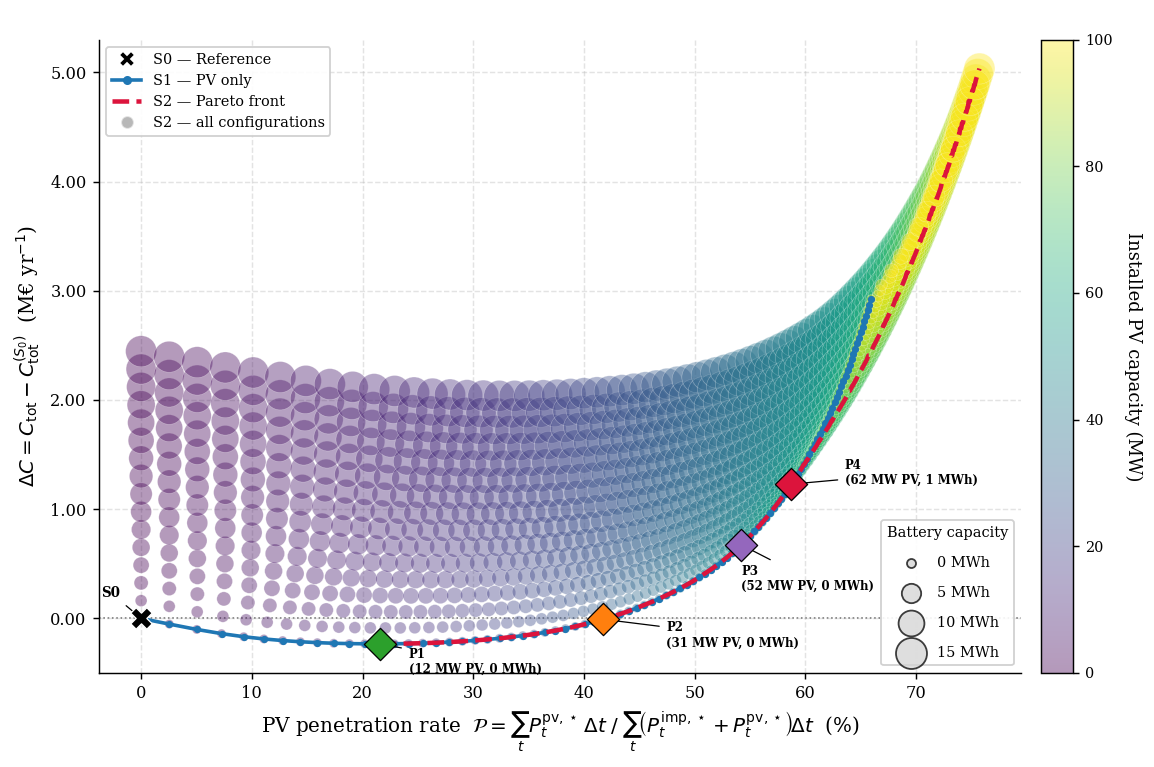

In [17]:
def plot_pareto_pv_share(
    df_s0, df_s1, df_s2, pareto,
    x_col: str,
    x_label: str,
    title: str,
    save_as: str,
) -> None:
    """Figure 2 — PV Share variant with black annotations, smaller text,
    main legend upper-left, battery legend lower-right."""
    cost_s0 = df_s0.iloc[0]["Total_Cost"] / 1e6

    def delta(series):
        return series / 1e6 - cost_s0

    p1, p2, p3, p4 = compute_key_points(df_s0, df_s2, pareto, x_col=x_col)

    KEY_POINTS = {
        "P1": {"row": p1, "c": "#2ca02c", "offset": (+16, -16)},
        "P2": {"row": p2, "c": "#ff7f0e", "offset": (+35, -15)},
        "P3": {"row": p3, "c": "#9467bd", "offset": (0, -25)},
        "P4": {"row": p4, "c": "crimson", "offset": (30, 0)},
    }

    fig, ax = plt.subplots(figsize=(9, 6))

    SIZE_MULT, BASE = 18, 25
    sc = ax.scatter(
        df_s2[x_col], delta(df_s2["Total_Cost"]),
        c=df_s2["PV_MW"], cmap="viridis",
        s=df_s2["Bat_MWh"] * SIZE_MULT + BASE,
        alpha=0.40, edgecolor="white", linewidth=0.3,
        zorder=2,
    )

    s1_sorted = df_s1.sort_values(x_col)
    ax.plot(
        s1_sorted[x_col], delta(s1_sorted["Total_Cost"]),
        color="#1f77b4", linewidth=2.0, marker="o", markersize=3,
        label="S1 — PV only", zorder=3,
    )

    ax.plot(
        pareto[x_col], delta(pareto["Total_Cost"]),
        color="crimson", linewidth=2.5, linestyle="--",
        label="S2 — Pareto front", zorder=4,
    )

    ax.axhline(0.0, color="black", linewidth=0.9,
               linestyle=":", alpha=0.55, zorder=1)
    xlim_left = ax.get_xlim()[0]
    #ax.text(
    #    xlim_left, 0.02, " Cost parity with S0",
    #    fontsize=7.5, color="black", alpha=0.65, va="bottom", ha="left",
    #)

    ax.scatter(
        0.0, 0.0,
        marker="X", s=140, color="black", zorder=10,
        edgecolor="white", linewidth=0.7, label="S0 — Reference",
    )
    ax.annotate(
        "S0", xy=(0.0, 0.0), xytext=(-22, +12),
        textcoords="offset points",
        fontsize=7.5, fontweight="bold", color="black",
        arrowprops=dict(arrowstyle="-", color="black", lw=0.7),
    )

    for key, pt in KEY_POINTS.items():
        row = pt["row"]
        d_cost = row["Total_Cost"] / 1e6 - cost_s0
        ax.scatter(
            row[x_col], d_cost,
            color=pt["c"], marker="D",
            s=160, zorder=9, edgecolor="black", linewidth=0.7,
        )
        dx, dy = pt["offset"]
        label = (f"{key}\n({int(row['PV_MW'])} MW PV"
                 f", {int(row['Bat_MWh'])} MWh)")
        ax.annotate(
            label,
            xy=(row[x_col], d_cost),
            xytext=(dx, dy), textcoords="offset points",
            fontsize=6.5, fontweight="bold", color="black",
            arrowprops=dict(arrowstyle="-", color="black", lw=0.7),
        )

    cbar = plt.colorbar(sc, ax=ax, pad=0.02, fraction=0.046)
    cbar.set_label("Installed PV capacity (MW)",
                   rotation=270, labelpad=16, fontsize=10)
    cbar.ax.tick_params(labelsize=8)

    bat_handles = [
        plt.scatter([], [], s=bat * SIZE_MULT + BASE,
                    c="lightgray", edgecolor="k", alpha=0.75,
                    label=f"{bat} MWh")
        for bat in [0, 5, 10, 15]
    ]
    bat_leg = ax.legend(
        handles=bat_handles,
        title="Battery capacity",
        loc="lower right", framealpha=0.9,
        labelspacing=1.1,
    )
    ax.add_artist(bat_leg)

    scen_handles = [
        Line2D([0], [0], linestyle="none", marker="X", ms=9,
               color="black", markeredgecolor="white",
               label="S0 — Reference"),
        Line2D([0], [0], color="#1f77b4", lw=2, marker="o", ms=4,
               label="S1 — PV only"),
        Line2D([0], [0], color="crimson", lw=2.5, ls="--",
               label="S2 — Pareto front"),
        Line2D([0], [0], linestyle="none", marker="o", ms=7,
               color="tab:gray", alpha=0.55, markeredgecolor="white",
               label="S2 — all configurations"),
    ]
    ax.legend(handles=scen_handles, loc="upper left", framealpha=0.9)

    ax.set_xlabel(x_label)
    ax.set_ylabel(
        r"$\Delta C = C_{\mathrm{tot}} - C_{\mathrm{tot}}^{(S_0)}$"
        r"  (M€ yr$^{-1}$)"
    )
    ax.set_title(title, weight="bold")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

    plt.tight_layout()
    plt.savefig(save_as)
    plt.show()


plot_pareto_pv_share(
    df_s0=df_s0,
    df_s1=df_s1,
    df_s2=df_s2,
    pareto=pareto_s2_share,
    x_col="PV_Share",
    x_label=(
        r"PV penetration rate  "
        r"$\mathcal{P} = "
        r"\sum_t P^{\mathrm{pv},\star}_t\,\Delta t"
        r"\;/\;"
        r"\sum_t\!\left(P^{\mathrm{imp},\star}_t + P^{\mathrm{pv},\star}_t\right)\!\Delta t$"
        r"  (%)"
    ),
    title=(' '),
    save_as="fig2_pareto_pv_share.eps",
)

## 10. Quantitative summary tables

Two tables are produced:

- **Table 1** — KPIs of the four canonical points P1–P4 of the
  RE-coverage Pareto front (extending the table referenced in the manuscript).
- **Table 2** — cost-optimal configuration of each scenario (\(S_0, S_1, S_2\))
  with savings relative to the all-grid reference.


In [18]:
def key_points_table(df_s0, df_s2, pareto, x_col="PV_Share") -> pd.DataFrame:
    """Tabular summary of S0 + the four canonical Pareto points."""
    p1, p2, p3, p4 = compute_key_points(df_s0, df_s2, pareto, x_col=x_col)
    s0 = df_s0.iloc[0]
    cost_s0 = s0["Total_Cost"] / 1e6

    descriptions = {
        "S0": "Reference — grid only",
        "P1": "Economic optimum",
        "P2": "Cost parity with S0",
        "P3": "Knee point",
        "P4": "Battery emergence",
    }

    rows = []
    for key, row in [("S0", s0), ("P1", p1), ("P2", p2), ("P3", p3), ("P4", p4)]:
        total_cost = row["Total_Cost"] / 1e6
        rows.append({
            "Point":               key,
            "Description":         descriptions[key],
            "PV (MW)":             int(row["PV_MW"]),
            "Battery (MWh)":       int(row["Bat_MWh"]),
            "RE Coverage (%)":     round(row["RE_Coverage"], 1),
            "PV Share (%)":        round(row["PV_Share"],    1),
            "CAPEX (M€/yr)":       round(row["CAPEX"]      / 1e6, 3),
            "OPEX (M€/yr)":        round(row["OPEX"]       / 1e6, 3),
            "Total Cost (M€/yr)":  round(total_cost, 3),
            "ΔCost vs S0 (M€/yr)": round(total_cost - cost_s0, 3),
        })

    return pd.DataFrame(rows).set_index("Point")


kp_table = key_points_table(df_s0, df_s2, pareto_s2_share, x_col="PV_Share")
kp_table.to_csv("pareto_key_points.csv")
kp_table


,Description,PV (MW),Battery (MWh),RE Coverage (%),PV Share (%),CAPEX (M€/yr),OPEX (M€/yr),Total Cost (M€/yr),ΔCost vs S0 (M€/yr)
Point,,,,,,,,,
S0,Reference — grid only,0,0,-7.5,0.0,0.000,4.081,4.081,0.000
P1,Economic optimum,12,0,15.7,21.5,0.679,3.169,3.848,-0.233
P2,Cost parity with S0,31,0,37.4,41.7,1.755,2.317,4.073,-0.008
P3,Knee point,52,0,50.8,54.2,2.944,1.810,4.755,0.674
P4,Battery emergence,62,1,55.5,58.7,3.675,1.635,5.310,1.229


In [19]:
def summarise(df_s0, df_s1, df_s2) -> pd.DataFrame:
    """Cost-optimal configuration of each scenario."""
    s0 = df_s0.iloc[0]
    s1 = df_s1.loc[df_s1["Total_Cost"].idxmin()]
    s2 = df_s2.loc[df_s2["Total_Cost"].idxmin()]

    rows = [
        {"Scenario": "S0 — Reference (grid only)",
         "PV (MW)": 0, "Battery (MWh)": 0,
         "CAPEX (M€/y)":      s0["CAPEX"]      / 1e6,
         "OPEX (M€/y)":       s0["OPEX"]       / 1e6,
         "Total cost (M€/y)": s0["Total_Cost"] / 1e6,
         "RE coverage (%)":   s0["RE_Coverage"],
         "PV share (%)":      s0["PV_Share"]},
        {"Scenario": "S1 — PV only (min cost)",
         "PV (MW)": s1["PV_MW"], "Battery (MWh)": 0,
         "CAPEX (M€/y)":      s1["CAPEX"]      / 1e6,
         "OPEX (M€/y)":       s1["OPEX"]       / 1e6,
         "Total cost (M€/y)": s1["Total_Cost"] / 1e6,
         "RE coverage (%)":   s1["RE_Coverage"],
         "PV share (%)":      s1["PV_Share"]},
        {"Scenario": "S2 — PV + Battery (min cost)",
         "PV (MW)": s2["PV_MW"], "Battery (MWh)": s2["Bat_MWh"],
         "CAPEX (M€/y)":      s2["CAPEX"]      / 1e6,
         "OPEX (M€/y)":       s2["OPEX"]       / 1e6,
         "Total cost (M€/y)": s2["Total_Cost"] / 1e6,
         "RE coverage (%)":   s2["RE_Coverage"],
         "PV share (%)":      s2["PV_Share"]},
    ]
    out = pd.DataFrame(rows)

    ref = out.iloc[0]["Total cost (M€/y)"]
    out["Saving vs S0 (%)"] = (ref - out["Total cost (M€/y)"]) / ref * 100
    return out.round(3)


summary_df = summarise(df_s0, df_s1, df_s2)
summary_df.to_csv("pareto_summary.csv", index=False)
summary_df


,Scenario,PV (MW),Battery (MWh),CAPEX (M€/y),OPEX (M€/y),Total cost (M€/y),RE coverage (%),PV share (%),Saving vs S0 (%)
0,S0 — Reference (grid only),0.0,0.0,0.000,4.081,4.081,-7.504,0.00,0.000
1,S1 — PV only (min cost),12.0,0.0,0.679,3.169,3.848,15.652,21.54,5.708
2,S2 — PV + Battery (min cost),12.0,0.0,0.679,3.169,3.848,15.652,21.54,5.708


## 11. Key takeaways

- **S0 (reference)** sets the annualised-cost ceiling: 100 % of the demand is
  imported from the grid, RE coverage = 0 %, PV share in mix = 0 %.
- **S1 (PV only)** displaces a significant share of grid imports, but without
  storage, any PV oversizing beyond the self-consumption saturation point is
  pure cost penalty (curtailment / export at low value).
- **S2 (PV + Battery)** dominates S1 on the Pareto plane for every coverage
  target above the PV-only saturation point: the battery shifts daytime PV
  surpluses to evening / night Shore-Power demand, turning curtailed kWh into
  avoided grid purchases.
- The **cost-optimal couple** P1 is the numerical answer to the sizing
  question — it minimises CAPEX + OPEX. The knee point P4 represents the best
  trade-off between cost increase and additional renewable share.
- The two Pareto views (Figures 1 and 2) tell consistent but distinct stories:
  RE Coverage emphasises the autonomy gain, whereas PV Share shows the
  composition of the energy actually supplied to the loads.

**Outputs** — All simulation results are saved to `pareto_all_scenarios.csv`,
the canonical-point KPIs to `pareto_key_points.csv`, and the scenario summary
to `pareto_summary.csv`. The two figures are exported as `fig1_pareto_re_coverage.png`
and `fig2_pareto_pv_share.png`.
